# EE 120 实验 4：非接触式心率监测
v1 - 2019 春：Dominic Carrano, Sidhant Kaushik, Shubhrakanti Ganguly, Miki Lustig   
v2 - 2019 秋：Dominic Carrano


In [2]:
from sklearn.decomposition import FastICA
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as pyd
%matplotlib inline

**注意：** 在上面的单元格运行之前，你可能需要先安装 `sklearn`。如果无法运行该单元格，请参考 https://scikit-learn.org/stable/install.html 中的安装说明。


# 背景

人类最重要的生命体征之一是心率，也就是心脏每分钟跳动的次数。对于成年人来说，典型的静息心率范围是每分钟 60 到 100 次。一般而言，运动能力更强的人平均静息心率会更低。例如，训练水平很高的人心率可能接近每分钟 40 或 50 次。

通常，心率监测需要使用昂贵的设备，这些设备配有专门为该目的设计的传感器系统。在本题中，我们将只用 Python 和手机摄像头，借助（快速）傅里叶变换来制作一个心率检测器。而且，和传统心率监测器不同，我们的方法是**非接触式**的：你只需要把拇指靠近摄像头，不需要和设备发生直接物理接触！

本实验旨在让你有机会处理真实世界的数据，并了解我们如何分析它的频谱，从而做出一个有实际用途的东西。本实验很大程度上基于文献 [1, 2] 中给出的描述。除了学习实用的频谱分析之外，我们也在通过这个实验参与科学方法：检验其他研究者已经发表的结果！

## 我们的监测器的总体思路

我们的检测器基于这样一个事实：心率会驱动血液在人体内流动。如果我们拍摄一个人的拇指近距离视频——其他身体部位也可以，但把拇指放在手机摄像头前最方便——并把视频的每个 RGB 通道看成一条单独的信号（视频中的每一张图像或“帧”都编码了红、绿、蓝（RGB）三个值），那么根据摄像头中不同波长的光对血液的捕捉程度，这些信号会包含该身体区域在录制期间血流变化的信息。但是，这份数据是视频，是三维的：一个维度用于时间、用来选择帧/图像；一个维度用于图像的 x 轴像素；一个维度用于图像的 y 轴像素；信号值则是像素强度。而在 EE 120 中，我们目前只知道如何处理一维信号。

## 致谢

我们非常感谢 Miki Lustig 教授给了我们这个实验的灵感。每年春季，他都会教授 EE 123：数字信号处理，这是 EE 120 的后续课程，会更深入地讲授信号处理，尤其是它的各种应用，其中很多应用会让你在真实硬件上实现和测试。EE 123 也包含 iPython notebook 实验，而本实验可以看作是你将在那门课中探索内容的一个小小预览。如果你喜欢这个实验，可以考虑选修 EE 123！


# Q1：数据采集与处理

在我们考虑设计心率监测算法之前，首先必须读入要使用的数据。


## 读入数据

本实验已经为你提供好了数据。这是一段 30 秒的视频，内容是一个拇指靠近 iPhone 摄像头。我们会用它来测试我们的算法。使用另一台独立的心率监测器，我们测得录制期间这个人的心率为 58 到 63 bpm。

我们已经提前为你做了一些处理：把视频转换成了一个 numpy 数组。这个数组是 4D 的：帧、y 像素、x 像素、RGB 分量。注意，当我们说视频是 3D 信号时，指的是每一个单独的 RGB 分量都是一个 3D 信号。这样你只需要把数据作为 numpy 数组读入，而不需要直接处理视频。2019 年春季有很多同学在安装将原始 `.mp4` 视频文件转换成 numpy 数组所需的库时遇到问题，因此我们做了这个改动来避免这个麻烦。

numpy 提供了非常方便的接口来保存和加载 numpy 数组，只需要调用 `np.load` 和 `np.save`。它们操作的是一种未压缩的 `.npy` 文件格式，用于存储数组。

运行下面的单元格，将视频数据加载为 numpy 数组。这可能需要几秒钟。


In [4]:
video_data = np.load("data1.npy")

在处理高维数据时，`np.info` 是一个非常方便的工具，可以快速查看对象属性的摘要。回想一下 Lab 1a 的 iPython 教程，输入 `[object]?` 会显示该对象的信息。实际上，当你这样输入时，iPython notebook 环境底层就是在对这个对象调用 `np.info`。我们来看一下能从视频数据中得到哪些信息。


In [5]:
np.info(video_data)

class:  ndarray
shape:  (926, 1080, 1920, 3)
strides:  (6220800, 5760, 3, 1)
itemsize:  1
aligned:  True
contiguous:  True
fortran:  False
data pointer: 0x73a24d760010
byteorder:  little
byteswap:  False
type: uint8


我们得到的最有用的属性之一是 `shape: (926, 1080, 1920, 3)`。如上所述，这段视频实际上是一个 4D numpy 数组，四个维度分别对应帧、y 像素、x 像素和 RGB 通道。

因此，当 numpy 告诉我们这个对象的形状是元组 `(926, 1080, 1920, 3)` 时，它的意思是：这个数组由 926 帧组成，每一帧都是一个 1920×1080 的像素网格（图像），每个像素由 3 个值组成，即 R、G、B 分量。总共来说，我们的数组包含 926 \* 1080 \* 1920 \* 3 = 5760460800 个值。我们可以通过读取 `ndarray` 的 `size` 属性来向 numpy 询问数组中有多少个元素，从而验证这一点：


In [6]:
video_data.size

5760460800

此外，我们可以做一个简单的合理性检查：由于视频是以每秒 30 帧拍摄的，而我们有 926 帧数据，所以这对应于 926 / 30 ≈ 30 秒的录制时长，符合预期。我们来播放一下这段视频！


In [8]:
pyd.Video("./data1.mov", width=300, height=300)

In [9]:
HTML("""
    <video alt="test" width="320" height="240" controls>
        <source src="data1.mov" type="video/mp4">
    </video>
""")

如果你仔细观察，会看到这个人的拇指在轻微地脉动。这个脉动发生的频率就是他的心率，而我们想要提取的正是这个信息。不过，在此之前，我们需要找到一种方法，把视频转换成更容易处理的一维信号。


## Q1a：空间平均

你第一次阅读上面的背景部分时，可能会觉得困惑：在 EE 120 中我们只知道如何处理一维信号，但视频却是三维信号！我们怎样把这个高维信号变成更容易处理、也更符合我们已学知识的形式呢？答案出乎意料地简单，而且还有其他好处：取平均！


### 信号维度

具体来说，我们要对视频做**空间平均**：首先，从每一帧中取出红色（R）、绿色（G）和蓝色（B）分量，得到三条独立的 3D 视频信号。这些信号仍然是 3D 的，因为它们本质上仍然是视频，只是去掉了另外两个颜色通道。信号的**维度**指的是，为了确定一个唯一的输出值，需要提供多少个输入参数。对于一维时域信号，我们输入 $n$（离散时间）或 $t$（连续时间），得到一个值。对于二维信号，例如图像，我们输入 x 和 y 坐标，得到一个灰度值或 RGB 三元组，具体取决于颜色的表示方式。无论如何，输出都是被唯一确定的。对于三维信号，例如视频，我们输入时间（选择哪一帧）以及 x、y 坐标，然后得到一个 RGB 颜色三元组。在这里，我们只是让输出不再是一个 RGB 三元组，而是三元组中的某一个值，即 R、G 或 B 分量。从根本上说，我们仍然需要 3 个输入才能得到一个输出，所以分离后的信号在平均之前仍然是 3D 的。


### 空间平均

然后，在每一个时间点，也就是每一帧上，我们取该帧图像中某个颜色通道在所有像素上的平均强度，把它作为该时间点的信号值。这样得到的信号就是一维的，表示 R、G、B 三个通道的平均强度随时间的变化。从现在开始，我们分别把这三个一维平均信号记为 $x_R(t)$、$x_G(t)$ 和 $x_B(t)$。严格来说，它们已经经过采样和离散化，并且在计算机中是以离散形式处理的；但它们来自连续现象——人体血流的视频记录——因此在建模时我们会把它们看成连续时间信号。对从连续现象采样得到的信号进行数字处理时，这种建模选择很常见。

空间平均同时完成了两件对心率监测器非常关键的事情：

- ***降维***。通过把每个颜色通道的图像平均成单个数字，我们把一个 3D 信号转换成了 1D 信号。这不仅更容易可视化和解释，而且需要处理的数据量也大大减少，从而让监测器的实现更高效。在实时应用中，这一点尤其重要！
- ***降噪***。回想 Lab 2，1D 移动平均滤波器是信号处理中最简单、但也最有效且应用最广泛的降噪技术之一，用来减少测量信号上叠加的噪声。空间平均也能达到类似效果：我们假设视频中的所有像素都来自这个人的拇指，因此它们对心率都同样有信息量。通过取平均，我们可以显著降低单个像素中的噪声，得到视频对这个人心率所提供信息的整体视角，而不是完全依赖某一个可能非常嘈杂的像素测量值。


运行下面的单元格来提取每个 RGB 通道的值。注意，前三个维度（帧索引以及每帧的空间坐标）被完整保留下来；我们只是选择要取三个 RGB 分量中的哪一个。


In [10]:
# 每个 RGB 分量对应的 3D 信号
xr_video = video_data[:, :, :, 0] 
xg_video = video_data[:, :, :, 1]
xb_video = video_data[:, :, :, 2]

### 你的任务

现在，我们有三条 3D 信号，希望对它们做空间平均，得到对应的一维版本。请在下面的单元格中完成这个操作。

函数 [np.mean](https://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html) 会很有用。**具体来说，你需要查看它的 `axis` 参数的文档。** 记住，我们要同时沿两个维度（轴）取平均：y 像素维度和 x 像素维度。也就是说，对于信号在每个时间点上的一帧图像，我们要把它转换成一个单独的数字。

由于需要处理的数据量很大，你的代码可能需要几秒钟才能运行完成。这也说明了为什么像 FFT 这样高效的信号处理算法，以及 numpy 中大量高效操作如此重要！


In [11]:
# TODO 在这里编写平均代码
xr = np.mean(xr_video, (1, 2))
xg = np.mean(xg_video, (1, 2))
xb = np.mean(xb_video, (1, 2))

现在，在下面的单元格中，我们会把三个通道的平均信号 $x_R(t), x_G(t), x_B(t)$ 画在**同一张** 16×4 的图中。我们会把 $x_R(t)$ 画成红色，$x_G(t)$ 画成绿色，$x_B(t)$ 画成蓝色，这样更容易观察。

绘图代码已经为你提供。如果你的平均操作正确，图像应该大致如下：

<img src="./unnormalized_spatialavgs.png" alt="drawing" style="width:800px; height=1200px"/>


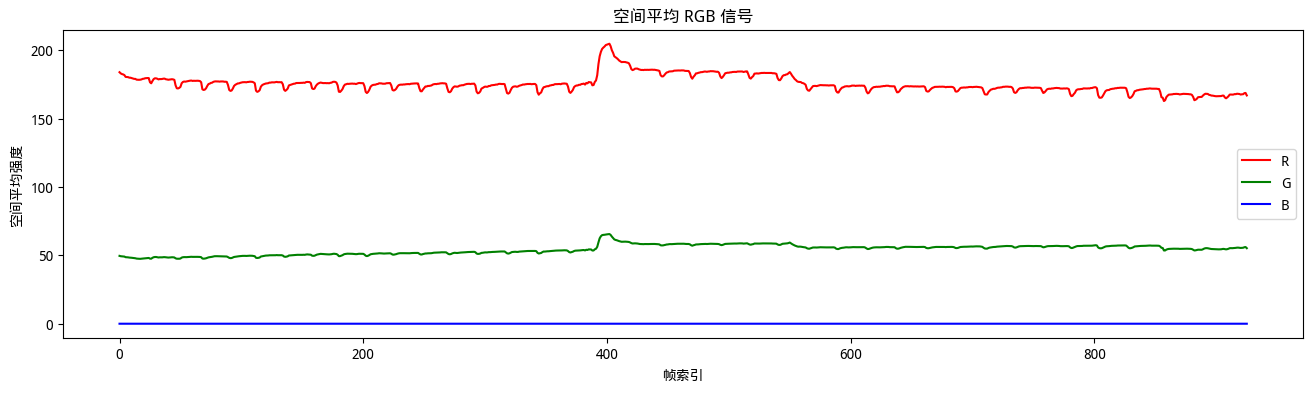

In [12]:
fig = plt.figure(figsize=(16, 4))
plt.plot(xr, color="r", label="R")
plt.plot(xg, color="g", label="G")
plt.plot(xb, color="b", label="B")
plt.legend()
plt.xlabel("帧索引")
plt.ylabel("空间平均强度")
plt.title("空间平均 RGB 信号")
plt.show()
fig.savefig("unnormalized_spatialavgs.png", dpi=300)

这张图有两个重要特征值得解释：

1. 这些信号大体上会上下跳动，这对应于心脏的实际跳动！注意它们或多或少是周期性的，因为人在静息时的心率在较短时间段内（这里是 30 秒）应该相对稳定。
2. 中间有一个很大的突变。这是因为拍摄视频的人在录制过程中移动了拇指。理想情况下，我们应该重新采集数据，但在处理真实世界数据时，这类问题经常出现，所以意识到它们很重要。


## Q1b：统计归一化

从上一部分得到的图可能有点令人困惑。为什么 R 分量比 G 分量强很多？同样地，为什么 G 又明显强于 B？为什么 R 和 G 看起来彼此之间有偏移？问题在于我们的信号还没有**归一化**。由于近距离观察时皮肤大多呈红色，R 分量自然会主导其他分量。虽然很容易得出一个看似方便的结论：红色信号一定对应血液，所以我们应该直接丢掉其他通道，只使用最强的红色信号；但文献 [2] 的作者表明，这种简单模型并不鲁棒。

事实证明，更好的做法是把 RGB 通道建模为不同“源信号”的混合，其中一个源信号来自人体血流，其他源信号则是噪声源，例如环境光变化或录制期间拇指移动。然后，我们要对这些混合信号进行“解混”，恢复出原始信号。在此之前，我们需要从统计意义上对信号进行归一化，使它们具有零均值和单位方差。这样做的原因是，我们稍后在 Q2 中会用到的解混算法高度依赖信号的统计性质，而这种归一化能带来更好的结果。可以这样理解：如果让你分离一碗混合物中的成分，你更愿意分离哪一碗？一碗由等量的小苏打、糖和面粉混合而成，还是一碗由 90% 小苏打、9% 糖和 1% 面粉混合而成？

在下面的单元格中完成统计归一化。同样地，每个信号应该都可以用一行代码完成。要让信号 $x(t)$ 具有零均值和单位方差，你可以先减去它的均值（$\mu_x$），再除以它的标准差（$\sigma_x$）。均值和标准差都是跨所有样本计算得到的实数：

$$x_\text{normalized}(t) = \dfrac{x(t) - \mu_x}{\sigma_x}$$

**提示：** 可以查看函数 [`np.mean`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html) 和 [`np.std`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.std.html)。


In [13]:
# TODO 在这里编写归一化代码
xr_normalized = (xr - np.mean(xr))/np.std(xr)
xg_normalized = (xg - np.mean(xg))/np.std(xg)
xb_normalized = (xb - np.mean(xb))/np.std(xb)

现在，运行下面的单元格来绘制空间平均后的信号。绘图代码同样已经为你提供。

如果你的代码正确，图像应该如下所示：

<img src="./normalized_avgs.png" alt="drawing" style="width:800px; height=1200px"/>


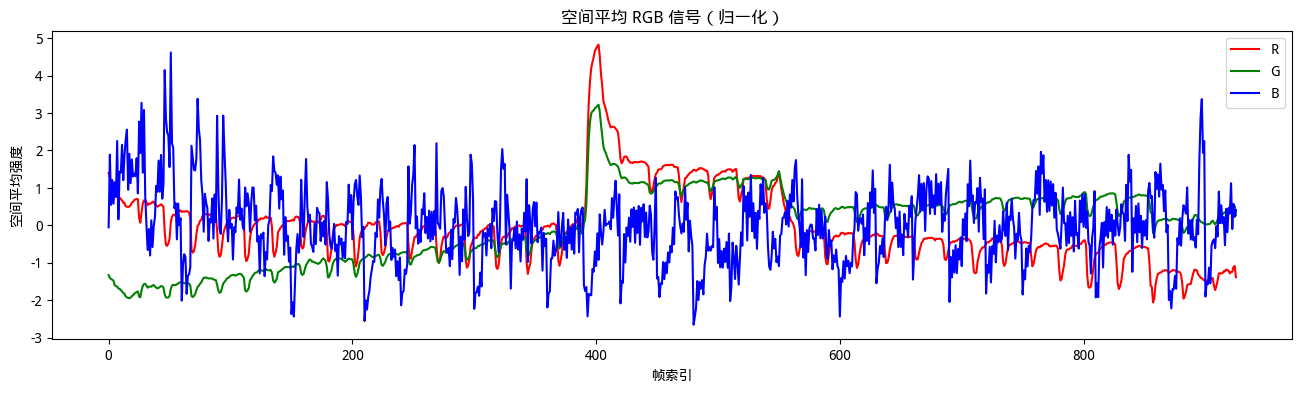

In [14]:
plt.figure(figsize=(16, 4))
plt.plot(xr_normalized, color="r", label="R")
plt.plot(xg_normalized, color="g", label="G")
plt.plot(xb_normalized, color="b", label="B")
plt.legend()
plt.xlabel("帧索引")
plt.ylabel("空间平均强度")
plt.title("空间平均 RGB 信号（归一化）")
plt.show()

## Q1c：盲源分离

在我们尝试从信号中提取心率信息之前，还有一件事情需要完成。前面提到过，所有使用我们正在实现的这种方法进行非接触式心率监测的研究都指出：如果把 RGB 通道建模为由不同**源信号**混合产生的信号，算法的鲁棒性会更好。在文献 [2] 中，作者指出，这种模型在多个医学应用中也很流行，用于去除噪声，包括心电图（electrocardiogram），而心电图正是医院中用于心率监测的一种方法。


### 建模信号混合

问题在于，我们并不知道源信号是什么，甚至也不知道是什么样的过程从这些源信号生成了我们的 RGB 信号。那我们应该如何恢复它们呢？这个问题被称为**盲源分离**（Blind Source Separation, BSS），其中“盲”指的是我们不知道真实的源信号。它确实是一个很有挑战性的问题。在工程中，当一个问题因为过于一般而显得太难时，我们通常会做一些简化假设。具体来说，我们假设：

- 源信号和 RGB 信号之间是线性关系，也就是说 RGB 信号是源信号的线性组合。虽然这未必完全真实，但它极大地简化了问题，并且至少给出了一个一阶近似。
- 各个源信号彼此独立。这个假设背后有统计学原因，你可以在参考文献中进一步了解。
- **源信号的数量等于观测信号的数量：这里是 3 个，分别对应 RGB 三个通道。** 这个假设的理由可以追溯到你在 EE 16AB 中学过的内容。假设我们有 $S$ 个源信号，$M$ 个测量信号（这里 $M = 3$，每个颜色通道一个）。
    - 如果 $M < S$，测量数量少于要求解的线性方程数量，得到的是**欠定**线性系统。通常，欠定系统有无穷多个解。
    - 如果 $M > S$，测量数量多于要求解的线性方程数量，得到的是**超定**线性系统，这类系统通常没有精确解。你在 EE 16A 中见过，最小二乘法可以在这种情况下从无穷多个可能中选择“最好”的解，也就是选择使平方误差和最小的解。然而，最小二乘需要同时知道输出（RGB 信号，我们确实有）和源信号（我们没有），并给出最优的组合系数。本质上，最小二乘只能处理权重未知的情况；而在这里，权重和源信号本身都未知！这正是“盲”源分离如此困难的原因。
    - 如果 $M = S$，测量数量刚好等于要求解的线性方程数量。这类系统通常有一个唯一解，因此最容易处理。

注意：对于有机器学习背景的同学来说，$S$，也就是源信号数量，通常会作为一个超参数，通过验证集来调节。在这里，我们把它固定为 3，也就是测量信号数量，因为这样做：

- 使问题在数值上更容易处理；
- 避免实现该系统时引入额外复杂性；
- 仍然能取得相当不错的效果。


### 独立成分分析

幸运的是，有许多方法可以解决这个问题，而我们将使用文献 [1, 2] 中采用的同一种方法：**独立成分分析**（Independent Component Analysis, ICA）。下面是一张取自 [2] 的很好的示意图，用框图展示了 ICA。在 [2] 中，研究者对人脸录像进行实时监测，并从脸颊区域提取心率信息，因此图的左侧从一个人的脸开始。相比本实验中为了简单而使用的拇指录像，这种方式往往能产生更干净的数据；但如果我们也这样做，就需要把实验的 80% 时间都花在计算机视觉技术上，只为在进入信号与系统分析之前选出相关区域。

<img src="ICAvisual.png" alt="Drawing" style="width: 50em;"/>

ICA 算法内部的工作原理远远超出了本课程范围，它涉及 EECS 126、EECS 127 和 EE 229A 中的思想。如果你对细节感兴趣，可以查看实验末尾给出的参考文献。不过对于我们的目的来说，把 ICA 看成一个黑箱就可以了：它接收我们的“混合”信号，执行解混，并返回源信号。


### 你的任务

在实验中，我们通常会让你自己实现算法，以便你更好地理解它们；但了解如何查找已有的库实现也同样重要。除非你刚刚自己发明了某个算法，否则它几乎一定已经存在于 numpy、scipy 或其他许多用 Python 编写的开源科学计算库中。而且在几乎所有情况下，库中的实现至少会比你在合理时间内写出的版本快 10 倍以上。更不用说，库函数通常已经经过了大量测试和调试。

请查看 [sklearn 对 ICA 的实现文档](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FastICA.html)，并用它对归一化后的信号执行 BSS。前面我们已经导入了 `FastICA`。**请将结果存储在一个名为 `sources` 的矩阵中。**

**提示：** 这个函数希望你的信号以单个**数据矩阵**的形式输入，其中每一列是一条单独的信号。首先，构造这个矩阵并传入函数。一个很好的合理性检查是：输入矩阵的 `np.shape()` 应该是 `(926, 3)`，因为我们有 926 帧（或者说，在把视频一维化之后，有 926 个信号值）和 3 条信号。


In [15]:
# TODO 创建数据矩阵
signal = np.vstack((xr_normalized, xg_normalized, xb_normalized)).T
signal.shape

(926, 3)

In [16]:
# TODO 在这里编写 ICA 代码
sources = FastICA().fit_transform(signal)


完成后，运行下面的绘图代码查看提取出的源信号！

如果你的 ICA 代码正确，结果可能看起来像这样：

<img src="./source_sigs1.png" alt="drawing" style="width:800px; height=1200px"/>

**不过，ICA 底层使用的是随机算法，每次运行时可能收敛到不同结果**，所以你也可能得到类似下面这样的图：

<img src="./source_sigs2.png" alt="drawing" style="width:800px; height=1200px"/>

甚至还可能像这样：

<img src="./source_sigs3.png" alt="drawing" style="width:800px; height=1200px">

幸运的是，这些差异并不会真正影响我们正确提取心率。我们接下来会查看组成每条信号的频率，而垂直偏移或重新缩放对频率影响不大；这些偏移和缩放正是这些图之间大部分差异的来源。回想一下，把信号乘以一个常数并不会滤除任何频率；由于傅里叶变换是线性的，所有频率成分只会被同一个常数缩放。理解这些性质有助于我们检查结果是否合理，这也是它们值得学习的原因 :)

如果你真的很担心，可以重新运行几次 ICA 代码，直到得到看起来类似这些图之一的结果。


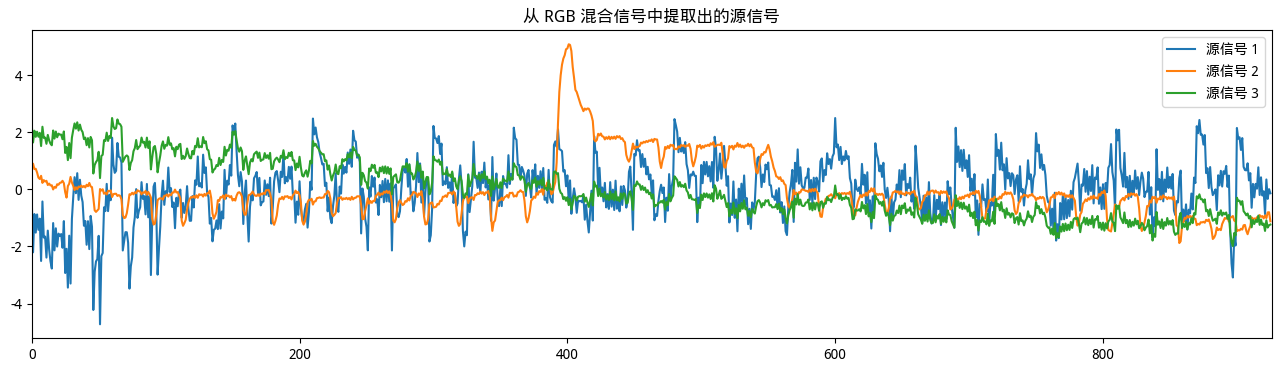

In [17]:
fig = plt.figure(figsize=(16, 4))
plt.plot(sources[:, 0], label="源信号 1")
plt.plot(sources[:, 1], label="源信号 2")
plt.plot(sources[:, 2], label="源信号 3")
plt.legend(loc="upper right")
plt.title("从 RGB 混合信号中提取出的源信号")
plt.xlim([0, len(sources[:, 0])])
plt.show()
fig.savefig("source_sigs3.png", dpi=300)

# Q2：通过功率谱进行频率分析

在前一个问题中，我们做了很多工作：从原始视频记录一直处理到提取可用于分析的源信号。信不信由你，我们的心率监测器几乎已经完成了！剩下唯一要做的事情，就是从这些信号中确定心率。

## 信号的功率谱

我们在 Q1c 中提取出的源信号，直接从时域图上看并不太有希望。在 Lab 3 中我们看到，可以使用 FFT 高效地计算 DFT，而 DFT 给出了信号 DTFT 的采样值。可以说，这让我们能够理解组成信号的各个振荡频率的强弱。对于我们的数据来说，这种解释非常自然：信号会随着人的心跳而上下波动，因此信号的**主频**，也就是使信号 DTFT 幅度最大的频率，正好就是心脏跳动的频率！回想一下，DTFT 是复值的，也就是说它同时包含幅度和相位信息。直观地说，幅度对应某个频率的“强度”，而相位编码的是该频率在信号中出现的位置。由于我们假设整个录制过程中人的心率近似恒定，所以我们只关心各个频率的强弱，而不关心它们在信号中具体出现的位置。

我们将利用寻找主频的思想来估计这个人的心率。更具体地说，我们想要信号的**功率谱**，它定义为信号傅里叶变换幅度的平方。

**也就是说，如果 $x[n]$ 的 DTFT 是 $X(\omega)$，那么它的功率谱定义为 $|X(\omega)|^2$。**

有趣的是，信号 $x[n]$ 的功率谱对应于 $x[n]$ 自相关的 DTFT。我们也可以使用幅度响应 $|X(\omega)|$，不进行平方，仍然能得到相同的结果（因为平方不会改变最大值的位置）。但这样频谱峰值，也就是 $|X(\omega)|$ 的局部最大值，不如平方后容易在图上分辨。而可视化在调试时往往非常有用。


## Q2a：计算功率谱

在下面的单元格中，计算三条源信号各自的功率谱。请将结果存储在名为 `PS` 的变量中。

**提示 1：** 你应该使用 `np.fft.fft` 的 `axis` 参数，直接在 ICA 返回的数据矩阵 `sources` 上用一行代码完成。至于取绝对值和平方，记住 numpy 是为向量化计算设计的：如果你对一个 numpy 数组调用一个标量函数，也就是把一个数映射到一个数的函数，不管数组有多少维（这里是二维，因为我们有一个矩阵），numpy 都会逐元素地应用它。

**提示 2：** 前面我们采用了每一列代表一条单独信号的约定。在确定传给 `axis` 的参数时，请记住这一点。一个很好的检查方法是：如果你做对了，`np.shape(PS)` 应该和 `np.shape(sources)` 相同。


In [10]:
sources.shape

(926, 3)

In [18]:
# TODO 在这里编写功率谱代码
PS = np.abs(np.fft.fft(sources, axis=0))**2

现在，我们来绘制这些信号的功率谱。绘图代码已经为你提供，其中有三点值得说明：

- **频率移位**。默认情况下，`np.fft.fft` 返回的 DTFT 采样值（也就是 DFT 系数）按从 $0$ 到 $2\pi$ 的顺序排列。这里我们调用 `np.fft.fftshift`，它会对结果做循环移位，使频率范围变为从 $-\pi$ 到 $\pi$。这在实践中很常见，因为幅度响应关于 $\omega = 0$ 的对称性会让图像更好看。
- **频率的物理解释**。我们这里的数据，也就是视频，是由手机摄像头以每秒 30 帧的速度拍摄得到的。这意味着每秒会得到 30 个新的数据样本，也就是 30 张拇指图像。因此，我们说这份数据的**采样频率**是 30 Hz，或者说数据是以 30 Hz 采样的。我们还没有详细讲采样。幸运的是，这里与我们的分析相关的只有一个结果：香农-奈奎斯特采样定理。简单来说，它指出如果以 $f$ Hz 对一个信号采样，那么你能观察到的最高频率对应于 $f / 2$ Hz。当我们对数据做 FFT 时，这意味着 x 轴虽然隐含地从 $-\pi$ 到 $\pi$（由于 DTFT 以 $2\pi$ 为周期，任何长度为 $2\pi$ 的区间都可以；但如上一点所说，这是最常用的选择），但在物理上对应于从 -15 Hz 到 15 Hz（因为离散时间中最高频率是 $\pi$，而我们能分辨出的最高实际频率是 15 Hz）。因此，在绘制 FFT 时，使用从 -15 到 15 的 x 轴标签很有用。
- **元信息**。现实中，一个人的心率通常不会低于 45 bpm（0.75 Hz），也不会高于 240 bpm（4 Hz），因此查看这个范围之外的频率没有意义；它们只是噪声。工程师在设计算法时，经常会利用关于系统或任务本身的知识，这称为**元信息**；这里正是这种情况。

由于第二点依赖于我们还没有正式讲过的内容，因此相关代码已经为你提供。


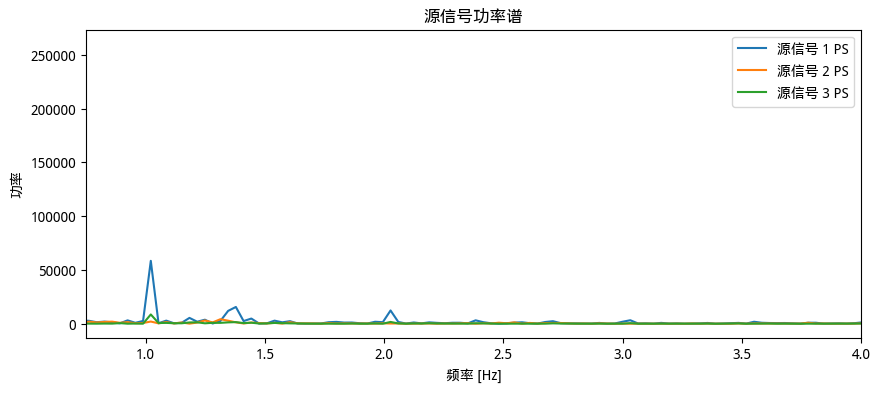

In [19]:
# 绘制功率谱
PS_shifted = np.fft.fftshift(PS, axes=0) # 移位到 -pi 到 pi
frame_rate = 30
freqs = np.linspace(-frame_rate / 2, frame_rate / 2, len(PS)) # -15 Hz 到 15 Hz 的范围
plt.figure(figsize=(10, 4))
plt.plot(freqs, PS_shifted[:, 0], label="源信号 1 PS")
plt.plot(freqs, PS_shifted[:, 1], label="源信号 2 PS")
plt.plot(freqs, PS_shifted[:, 2], label="源信号 3 PS")
plt.title("源信号功率谱")
plt.xlabel("频率 [Hz]")
plt.ylabel("功率")
plt.legend(loc="upper right")
plt.xlim([.75, 4]) # 将显示范围限制在合理的心率频率范围内
plt.show()

其中一个源信号会明显强于另外两个。如果你的功率谱代码正确，你应该能在其中看到三个清晰的峰值：一个刚好在 1.0 Hz 之后，一个大约在 1.4 Hz 附近，还有一个刚好在 2.0 Hz 之后。接近 1.0 Hz 的那个峰应该是最强的。


为了让下一部分更简单，我们可以把三条功率谱合并成一条：在每个频率点上只保留三个值中的最大值。直观上，最大的峰值应该对应与心跳有关的信息，所以我们只关心每个频率点上检测到的最大值。


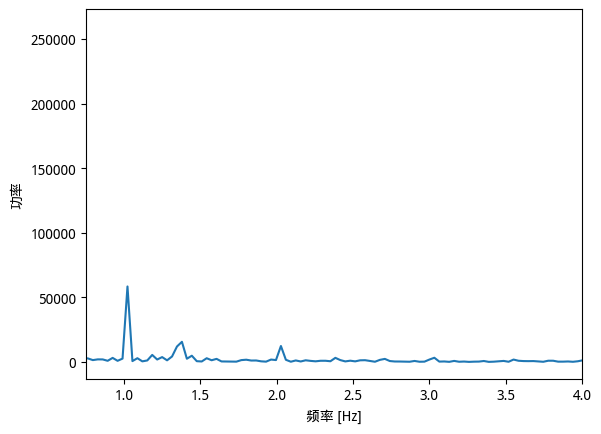

In [20]:
max_ps = np.max(PS_shifted, axis=1)
plt.plot(freqs, max_ps)
plt.xlim([.75, 4])
plt.xlabel("频率 [Hz]")
plt.ylabel("功率")
plt.show()

从这里开始，我们只处理 `max_ps`，而不再分别处理 3 条功率谱。


## Q2b：提取主频

那个最强的峰出现在主频处，而它正是来自这个人的心跳！我们只需要写一些代码提取这个频率，再乘以 60（因为我们想要的是每分钟心跳次数，而不是每秒心跳次数），就能计算出这个人的心率。首先，我们定义一些有用的常量。


In [22]:
SEC_PER_MIN = 60
MIN_BPM = 45
MAX_BPM = 240

现在，在下面的单元格中，提取主频 $f_{d}$，然后按照以下步骤计算心率：

- 计算 `freqs`（前面已经为你定义）中介于 60 bpm 和 240 bpm 之间的索引。可以查看 [np.where](https://docs.scipy.org/doc/numpy/reference/generated/numpy.where.html) 和 [np.bitwise_and](https://docs.scipy.org/doc/numpy/reference/generated/numpy.bitwise_and.html)，了解如何完成这一步。
- 将 `freqs` 和 `max_ps` 都裁剪到这个范围内。
- 从裁剪后的频率数组中提取 $f_d$：它是裁剪后的功率谱取最大值处对应的频率元素。可以查看 [np.argmax](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argmax.html)。
- 通过将 $f_d$ 乘以 `SEC_PER_MIN` 来计算心率。**请将结果存储在名为 `hr` 的变量中。**


In [23]:
# TODO 在这里编写代码！
min_freq = MIN_BPM / SEC_PER_MIN
max_freq = MAX_BPM / SEC_PER_MIN

mask = np.bitwise_and(freqs >= min_freq, freqs <= max_freq)

freqs = freqs[mask]
max_ps = max_ps[mask]
fd = freqs[np.argmax(max_ps)]
hr = SEC_PER_MIN * fd

完成上述操作后，运行下面的单元格，看看你最终得到的心率是多少。作为参考，这个人的实际心率由独立监测器测得，在 58 到 63 bpm 之间。看看你的结果与它相比如何！


In [24]:
print("心率：{0} bpm".format(round(hr, 1)))

心率：61.3 bpm


# Q3：在更多数据上测试

现在，我们已经完成了心率检测算法的所有实现工作，接下来把它放到一些真实数据上测试一下！我们拍摄了几段视频，并已经为你转换成 `.npy` 文件；运行下一个单元格来加载它们。第一个数据集就是我们在上面 Q1 和 Q2 中一直使用的同一个数据集。

这个单元格会运行一段时间：这些 `.npy` 文件是未压缩的，大小从 500 MB 到 6 GB 以上不等。


In [30]:
data1 = np.load("data1.npy")
data2 = np.load("data2.npy")
data3 = np.load("data3.npy")
data4 = np.load("data4.npy")

现在，根据前面所有部分填写下面的函数，使我们能够通过一次函数调用，直接从原始视频文件输出心率。你不需要写任何新的算法代码。


In [31]:
def meas_hr(raw_data, min_bpm=45, max_bpm=240, frame_rate=30):
    """
    给定一个人的拇指视频记录（raw_data），返回该记录时段内的平均心率。
    """
    SEC_PER_MIN = 60
    
    # TODO ->（Q1 引入）提取分量
    xr_video = raw_data[:, :, :, 0] 
    xg_video = raw_data[:, :, :, 1]
    xb_video = raw_data[:, :, :, 2]
    
    # TODO ->（Q1a）取平均
    xr = np.mean(xr_video, (1, 2))
    xg = np.mean(xg_video, (1, 2))
    xb = np.mean(xb_video, (1, 2))
    
    # TODO ->（Q1b）归一化
    xr_nor = (xr - np.mean(xr))/np.std(xr)
    xg_nor = (xg - np.mean(xg))/np.std(xg)
    xb_nor = (xb - np.mean(xb))/np.std(xb)
        
    # TODO ->（Q1c）创建数据矩阵
    signals = np.vstack((xr_nor, xg_nor, xb_nor)).T
        
    # TODO ->（Q1c）使用 ICA 得到源信号矩阵
    sources = FastICA().fit_transform(signals)
        
    # TODO ->（Q2a）计算功率谱
    PS_shifted = np.fft.fftshift(np.abs(np.fft.fft(sources, axis=0))**2, axes=0)
    max_ps = np.max(PS_shifted, axis=1)
    
    # TODO ->（Q2b）提取主频并转换为心率
    freqs = np.linspace(-frame_rate / 2, frame_rate/2, len(max_ps))
    mask = np.bitwise_and(freqs >= min_bpm/60, freqs <= max_bpm/60)
    freqs = freqs[mask]
    max_ps = max_ps[mask]
    return SEC_PER_MIN * freqs[np.argmax(max_ps)]
    

    
    
    

完成后，运行下面的单元格试用你的心率监测器！作为参考，下面列出了每个数据集中被测者的真实心率：

- 数据集 1：58–63 bpm（静息）
- 数据集 2：66–71 bpm（静息）
- 数据集 3：76–82 bpm（行走）
- 数据集 4：68–70 bpm（静息）

如果有几个结果不正确，不用担心——处理真实世界数据时这种情况很常见！你在 Q2a 中已经看到，可能会出现多个峰值。我们发现，当算法给出错误结果时，通常不是因为对应真实心率的峰不存在，而是因为存在另一个更强的峰，这个峰很可能由多个噪声源共同造成。一旦你的代码工作正常，最大的误差来源通常就是噪声数据——把拇指放在手机摄像头前并不会产生最高质量的记录。你可以尝试调节上下阈值（`min_bpm` 和 `max_bpm`），看看随着你排除更多可能性，结果会如何变化！

从评分角度看，我们只关心你能否把前面构建的各个部分综合成一个函数；这里往下的内容主要是供你自由尝试。


In [32]:
def disp_hr(hr, dataset):
    print("平均心率（数据集 {0}）：{1} bpm".format(dataset, round(hr, 1)))

In [33]:
disp_hr(meas_hr(data1), 1)
disp_hr(meas_hr(data2), 2)
disp_hr(meas_hr(data3), 3)
disp_hr(meas_hr(data4), 4)

平均心率（数据集 1）：61.3 bpm
平均心率（数据集 2）：48.8 bpm
平均心率（数据集 3）：78.8 bpm
平均心率（数据集 4）：69.3 bpm


In [29]:
# 如果我们把第 2 个数据集的下限设为 50，会让结果变正确吗？
disp_hr(meas_hr(data2, min_bpm=50), 2)

平均心率（数据集 2）：69.6 bpm


# 进一步改进我们的心率监测器

我们成功采用了其他研究者提出的方法，自己实现了它，并得到了一些很酷的结果！虽然我们确实遵循了文献 [1, 2] 中用于心率监测的**方法**（除了我们的数据采集方式有所不同），但我们这个具体**实现**仍然有一些可以改进的地方：

- **计算效率。** 我们只从 ICA 部分开始对代码做了向量化。为了让代码更快，可以从一开始就创建数据矩阵，让每个通道作为一列，就像后面做的一样。
- **时间分辨率。** 我们的监测器根据输入的数据计算一个平均心率。对于职业运动队来说，一个常见任务是在各种训练过程中监测运动员的心率。由于我们只计算一个平均值，所以会丢失心率随时间变化的所有信息（如果这个人的心率是恒定的，那就不会丢失什么；但很多情况下心率并不是恒定的）。为了解决这个问题，我们可以在数据上滑动一个移动窗口，例如用 30 秒窗口计算心率，然后向前移动 1 秒重新计算，如此反复，这样每秒都能得到一个新的估计。这正是文献 [2] 的作者最终采用的方法。

我们鼓励你在课后自己尝试这些改进，也可以采集你自己拇指的数据，甚至采集其他来源的数据，例如其他手指或脸颊。不过这里不要求你实现这些内容。在 [1, 2] 中，作者使用人脸，并应用计算机视觉技术选择用于心率检测的**感兴趣区域**（Region of Interest, ROI）。这些技术超出了本课程范围（如果想更深入学习二维和三维信号处理技术，可以参考 EE 225B 和 CS 280），所以我们这里通过使用拇指来考虑一个简化版本，尽管这会牺牲一些数据质量。


# 参考文献

[1] *Measuring Heart Rate from Video*. [链接](https://web.stanford.edu/class/cs231a/prev_projects_2016/finalReport.pdf)。  
[2] *Non-contact, automated cardiac pulse measurements using video imaging and blind source separation.*
[链接](https://www.osapublishing.org/DirectPDFAccess/3C66D9B3-E3ED-58AA-DF056147993BD0BD_199381/oe-18-10-10762.pdf?da=1&id=199381&seq=0&mobile=no)。   
[3] *Camera-based Heart Rate Monitoring*. [链接](http://www2.imm.dtu.dk/pubdb/views/edoc_download.php/6796/pdf/imm6796.pdf)。    
[4] Wikipedia page on ICA. [链接](https://en.wikipedia.org/wiki/Independent_component_analysis)。  
[5] *Independent component analysis, A new concept?* [链接](http://mlsp.cs.cmu.edu/courses/fall2012/lectures/ICA.pdf)。这是 ICA 的原始论文，引用次数超过 10000 次！！！   
[6] *Independent component analysis.* [链接](https://www.cs.helsinki.fi/u/ahyvarin/papers/bookfinal_ICA.pdf)。一本完整的 ICA 教材。  
[7] *A Tutorial on Independent Component Analysis.* [链接](https://arxiv.org/pdf/1404.2986.pdf)。所谓**教程论文**，是指以解释某个概念为目的，而不是提出原创研究成果的论文。
